# Time Complexity Analysis
Reads the CSV generated by `time_complexity_runner.ipynb` and plots rounds-to-convergence vs number of nodes.

Re-run this freely without re-running simulations.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr
from pathlib import Path

OUT_DIR  = Path("../output/time_complexity")
CSV_PATH = sorted(OUT_DIR.glob("time_complexity_*.csv"))[-1]  # most recent
print("Loading:", CSV_PATH)

Loading: ../output/time_complexity/time_complexity_a4-30_b4-30_n100.csv


In [27]:
df = pd.read_csv(CSV_PATH)

# Only use successful runs (mod_start should be 100%, but guard anyway)
df = df[df["success"] == 1].copy()
print(f"{len(df):,} successful runs loaded")
print(f"n_nodes range: {df.n_nodes.min()} to {df.n_nodes.max()}")
print(f"unique n_nodes values: {df.n_nodes.nunique()}")
print(f"unique (a,b) pairs: {df[['a','b']].drop_duplicates().shape[0]}")
df.head()

72,900 successful runs loaded
n_nodes range: 16 to 900
unique n_nodes values: 274
unique (a,b) pairs: 729


,a,b,n_nodes,steps,success
0,4,6,24,30,1
1,4,6,24,31,1
2,4,6,24,15,1
3,4,6,24,17,1
4,4,6,24,17,1


In [28]:
# Aggregate: mean and std of steps per (a, b) pair
agg = df.groupby(["a", "b", "n_nodes"])["steps"].agg(["mean", "std", "median"]).reset_index()
agg.columns = ["a", "b", "n_nodes", "mean_steps", "std_steps", "median_steps"]
agg = agg.sort_values("n_nodes")
agg.head(10)

,a,b,n_nodes,mean_steps,std_steps,median_steps
0,4,4,16,12.80,2.581989,13.0
1,4,5,20,17.51,3.546217,18.5
27,5,4,20,14.52,3.217628,14.5
2,4,6,24,20.55,4.438980,20.0
54,6,4,24,17.54,3.721138,17.0
28,5,5,25,18.09,4.276067,18.0
3,4,7,28,25.15,5.507341,25.0
81,7,4,28,18.69,4.133370,18.0
29,5,6,30,23.58,4.866252,23.0
55,6,5,30,22.07,4.870557,21.0


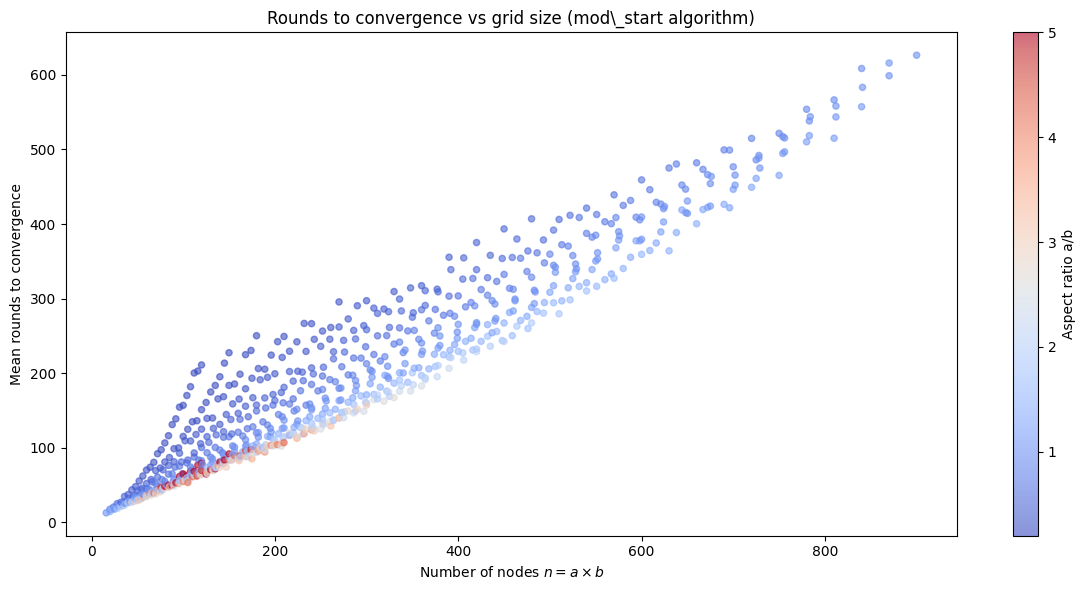

In [29]:
# --- Plot 1: Scatter of all (a,b) pairs, coloured by aspect ratio ---
fig, ax = plt.subplots(figsize=(12, 6))

aspect = agg["a"] / agg["b"]   # <1 tall, =1 square, >1 wide
sc = ax.scatter(
    agg["n_nodes"], agg["mean_steps"],
    c=aspect, cmap="coolwarm", alpha=0.6, s=20,
    vmin=0.2, vmax=5
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Aspect ratio a/b")

ax.set_xlabel("Number of nodes $n = a \\times b$")
ax.set_ylabel("Mean rounds to convergence")
ax.set_title("Rounds to convergence vs grid size (mod\_start algorithm)")
plt.tight_layout()
plt.savefig(OUT_DIR / "scatter_rounds_vs_nodes.png", dpi=200)
plt.show()

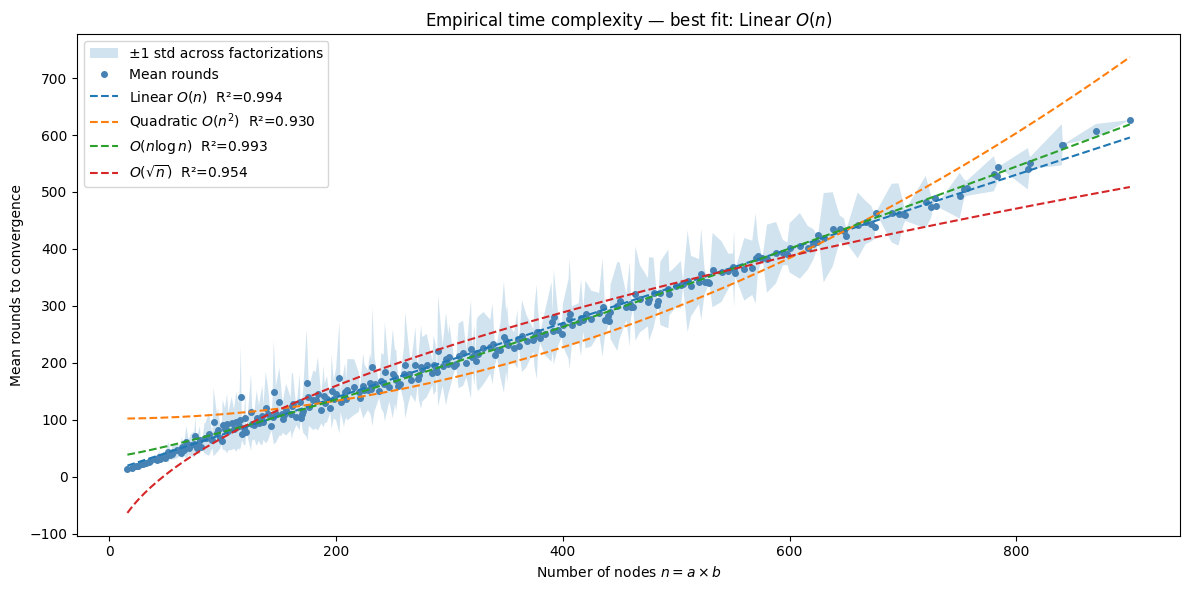

Best fit: Linear $O(n)$  (R² = 0.9936)


In [30]:
# --- Plot 2: Mean per n_nodes with error band, plus curve fits ---
per_n = agg.groupby("n_nodes").agg(
    mean_steps=("mean_steps", "mean"),
    std_steps=("mean_steps", "std")
).reset_index()

x = per_n["n_nodes"].values.astype(float)
y = per_n["mean_steps"].values.astype(float)

# Candidate fit functions
fits = {
    "Linear $O(n)$":       (lambda n, a, b: a * n + b,                  [0.1, 1]),
    "Quadratic $O(n^2)$":  (lambda n, a, b: a * n**2 + b,               [1e-4, 1]),
    "$O(n \\log n)$":      (lambda n, a, b: a * n * np.log(n) + b,      [0.01, 1]),
    "$O(\\sqrt{n})$":      (lambda n, a, b: a * np.sqrt(n) + b,         [1, 1]),
}

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(
    per_n["n_nodes"],
    per_n["mean_steps"] - per_n["std_steps"].fillna(0),
    per_n["mean_steps"] + per_n["std_steps"].fillna(0),
    alpha=0.2, label="±1 std across factorizations"
)
ax.plot(x, y, "o", markersize=4, label="Mean rounds", color="steelblue")

x_smooth = np.linspace(x.min(), x.max(), 300)
best_r2 = -np.inf
best_label = None

for label, (fn, p0) in fits.items():
    try:
        popt, _ = curve_fit(fn, x, y, p0=p0, maxfev=5000)
        y_pred = fn(x, *popt)
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r2 = 1 - ss_res / ss_tot
        ax.plot(x_smooth, fn(x_smooth, *popt), "--", linewidth=1.5, label=f"{label}  R²={r2:.3f}")
        if r2 > best_r2:
            best_r2 = r2
            best_label = label
    except Exception as e:
        print(f"Fit failed for {label}: {e}")

ax.set_xlabel("Number of nodes $n = a \\times b$")
ax.set_ylabel("Mean rounds to convergence")
ax.set_title(f"Empirical time complexity — best fit: {best_label}")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "complexity_curve_fit.png", dpi=200)
plt.show()
print(f"Best fit: {best_label}  (R² = {best_r2:.4f})")

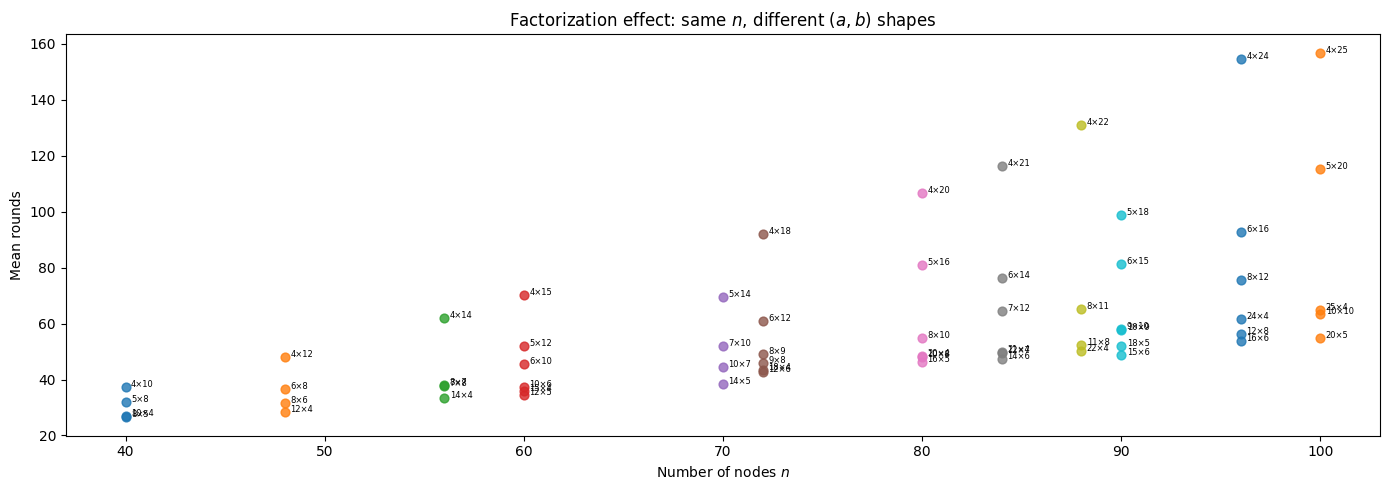

In [31]:
# --- Plot 3: Same n, different (a,b) — show factorization effect ---
# Pick n_nodes values that have the most distinct (a,b) factorizations
factorization_counts = agg.groupby("n_nodes").size()
interesting_n = factorization_counts[factorization_counts >= 4].index.tolist()

sample_n = sorted(interesting_n)[:12]  # first 12 interesting sizes
subset = agg[agg["n_nodes"].isin(sample_n)].copy()
subset["label"] = subset["a"].astype(str) + "×" + subset["b"].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))
for n_val in sample_n:
    group = subset[subset["n_nodes"] == n_val]
    ax.scatter([n_val] * len(group), group["mean_steps"], s=40, alpha=0.8)
    for _, row in group.iterrows():
        ax.annotate(row["label"], (n_val, row["mean_steps"]),
                    textcoords="offset points", xytext=(4, 0), fontsize=6)

ax.set_xlabel("Number of nodes $n$")
ax.set_ylabel("Mean rounds")
ax.set_title("Factorization effect: same $n$, different $(a,b)$ shapes")
plt.tight_layout()
plt.savefig(OUT_DIR / "factorization_effect.png", dpi=200)
plt.show()

In [32]:
# --- Summary table ---
print("Summary statistics per n_nodes (averaged across all factorizations):")
summary = per_n.copy()
summary.columns = ["n_nodes", "mean_rounds", "std_rounds"]
print(summary.to_string(index=False))

Summary statistics per n_nodes (averaged across all factorizations):
 n_nodes  mean_rounds  std_rounds
      16    12.800000         NaN
      20    16.015000    2.114249
      24    19.045000    2.128391
      25    18.090000         NaN
      28    21.920000    4.567910
      30    22.825000    1.067731
      32    24.145000    4.094148
      35    24.990000    3.054701
      36    27.940000    6.041962
      40    30.580000    5.075398
      42    29.310000    1.951615
      44    35.300000   11.681404
      45    31.365000    4.391133
      48    36.205000    8.495024
      49    33.580000         NaN
      50    36.150000    8.810550
      52    42.815000   17.911015
      54    38.430000    7.523616
      55    38.960000    9.659079
      56    42.847500   13.057609
      60    45.915000   13.643268
      63    41.700000    3.365828
      64    51.866667   19.286011
      65    46.950000   14.792674
      66    47.125000   10.245977
      68    60.025000   28.998449
      70    5

## Fixed-$n$ Shape Analysis
For a fixed number of nodes $n = a \times b$, different grid shapes (factorizations) may converge in different numbers of rounds.
The following plots isolate this **shape effect** from the overall size trend.

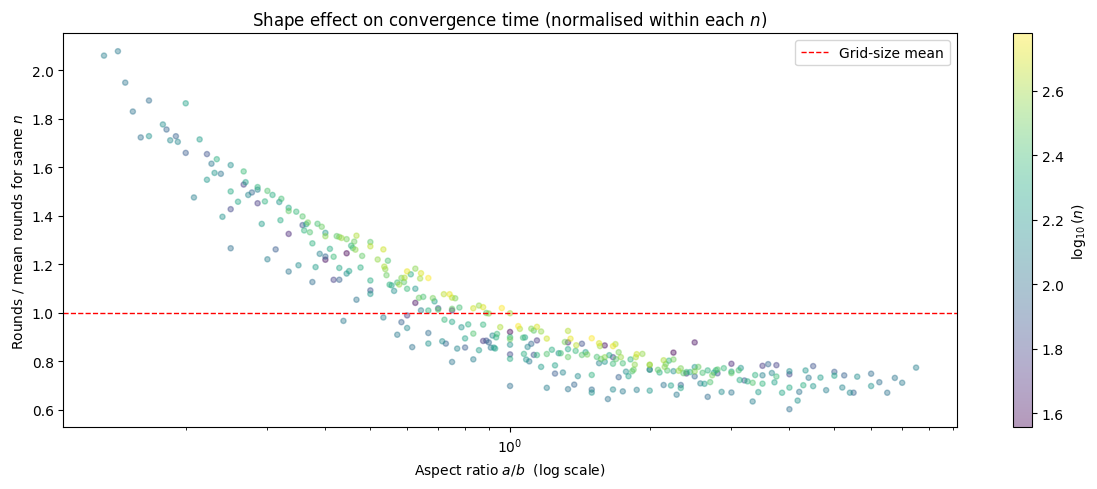

Values > 1 → slower than average for that n;  < 1 → faster


In [33]:
# --- Plot 4: Normalised aspect-ratio effect (shape effect stripped of size) ---
# For each (a,b) pair, divide mean_steps by the mean across ALL shapes with the same n.
# A value > 1 means that shape is slower than average for its n; < 1 means faster.

n_mean = agg.groupby("n_nodes")["mean_steps"].transform("mean")
agg["norm_steps"] = agg["mean_steps"] / n_mean
agg["aspect"]     = agg["a"] / agg["b"]   # < 1 → tall, 1 → square, > 1 → wide

# Only use n_nodes that have >= 3 distinct shapes (otherwise normalisation is trivial)
valid_n = agg.groupby("n_nodes")["norm_steps"].transform("count") >= 3
plot_df = agg[valid_n].copy()

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(
    plot_df["aspect"], plot_df["norm_steps"],
    c=np.log10(plot_df["n_nodes"]), cmap="viridis", alpha=0.4, s=14
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("$\\log_{10}(n)$")
ax.axhline(1.0, color="red", linewidth=1, linestyle="--", label="Grid-size mean")
ax.set_xscale("log")
ax.set_xlabel("Aspect ratio $a/b$  (log scale)")
ax.set_ylabel("Rounds / mean rounds for same $n$")
ax.set_title("Shape effect on convergence time (normalised within each $n$)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "shape_effect_normalised.png", dpi=200)
plt.show()
print("Values > 1 → slower than average for that n;  < 1 → faster")

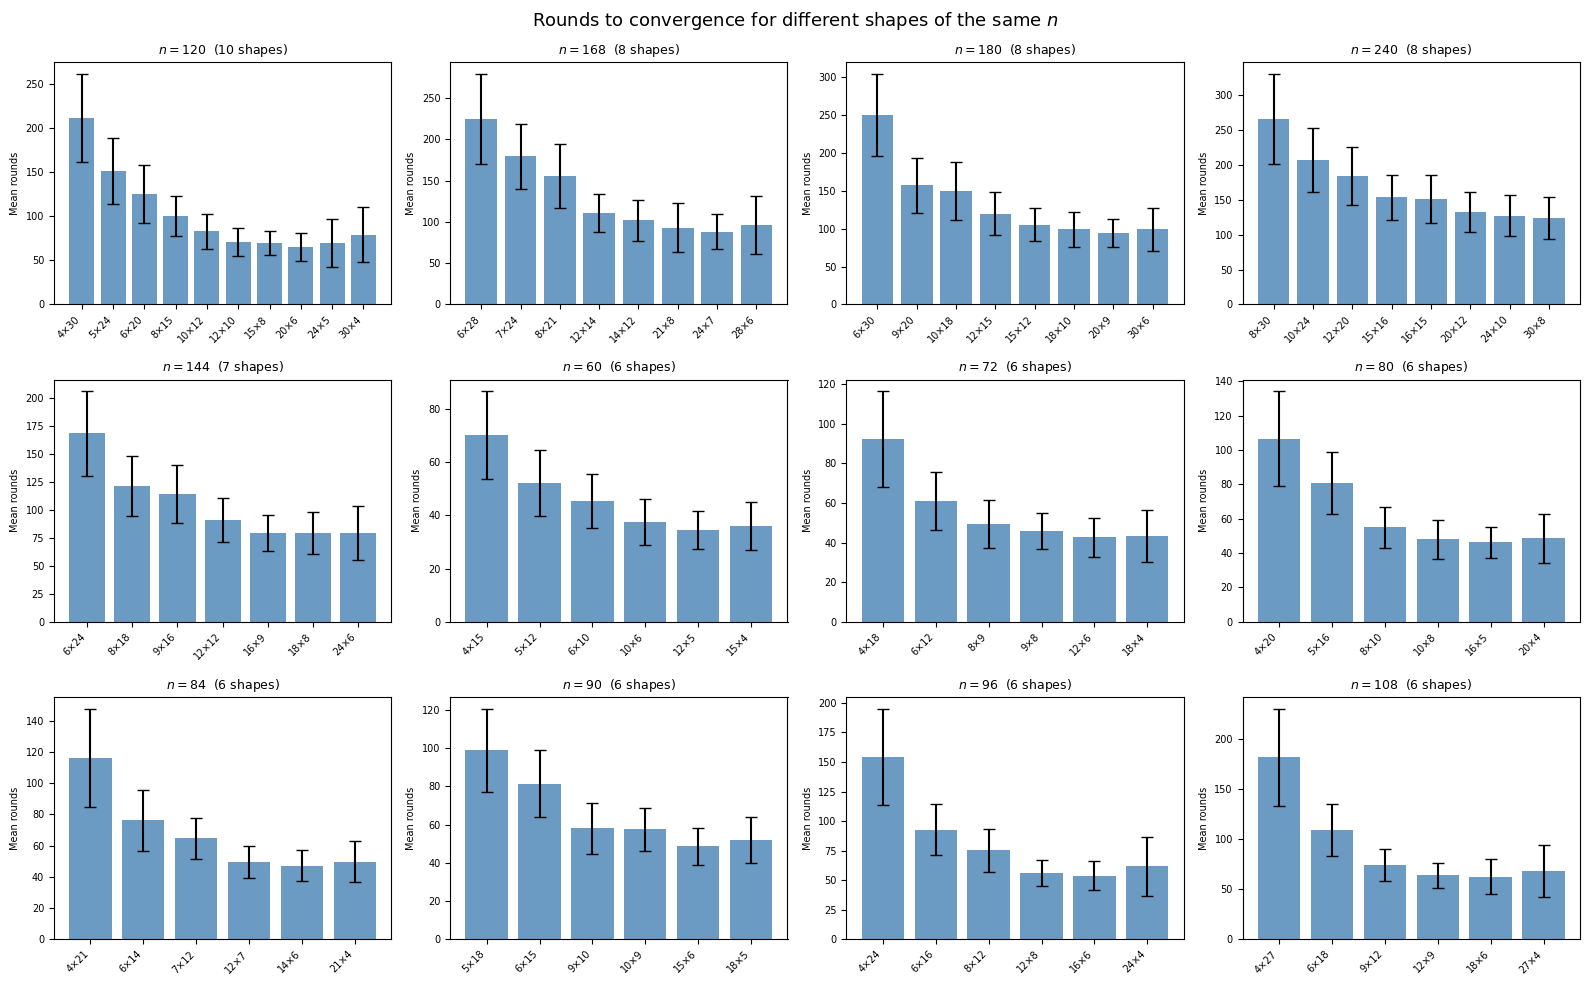

In [34]:
# --- Plot 5: Per-n subplots — mean rounds vs aspect ratio for highly factorable n ---
# Pick n values with the most distinct (a,b) pairs in the dataset.
n_shape_counts = agg.groupby("n_nodes").size()
# Take top-12 most factorable n values
top_n = n_shape_counts.nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10), sharey=False)
axes = axes.flatten()

for ax, n_val in zip(axes, top_n):
    group = agg[agg["n_nodes"] == n_val].sort_values("aspect")
    labels = group["a"].astype(str) + "×" + group["b"].astype(str)
    ax.bar(range(len(group)), group["mean_steps"],
           yerr=group["std_steps"], capsize=4, color="steelblue", alpha=0.8)
    ax.set_xticks(range(len(group)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"$n = {n_val}$  ({len(group)} shapes)", fontsize=9)
    ax.set_ylabel("Mean rounds", fontsize=7)
    ax.yaxis.set_tick_params(labelsize=7)

fig.suptitle("Rounds to convergence for different shapes of the same $n$", fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / "fixed_n_shape_subplots.png", dpi=200)
plt.show()

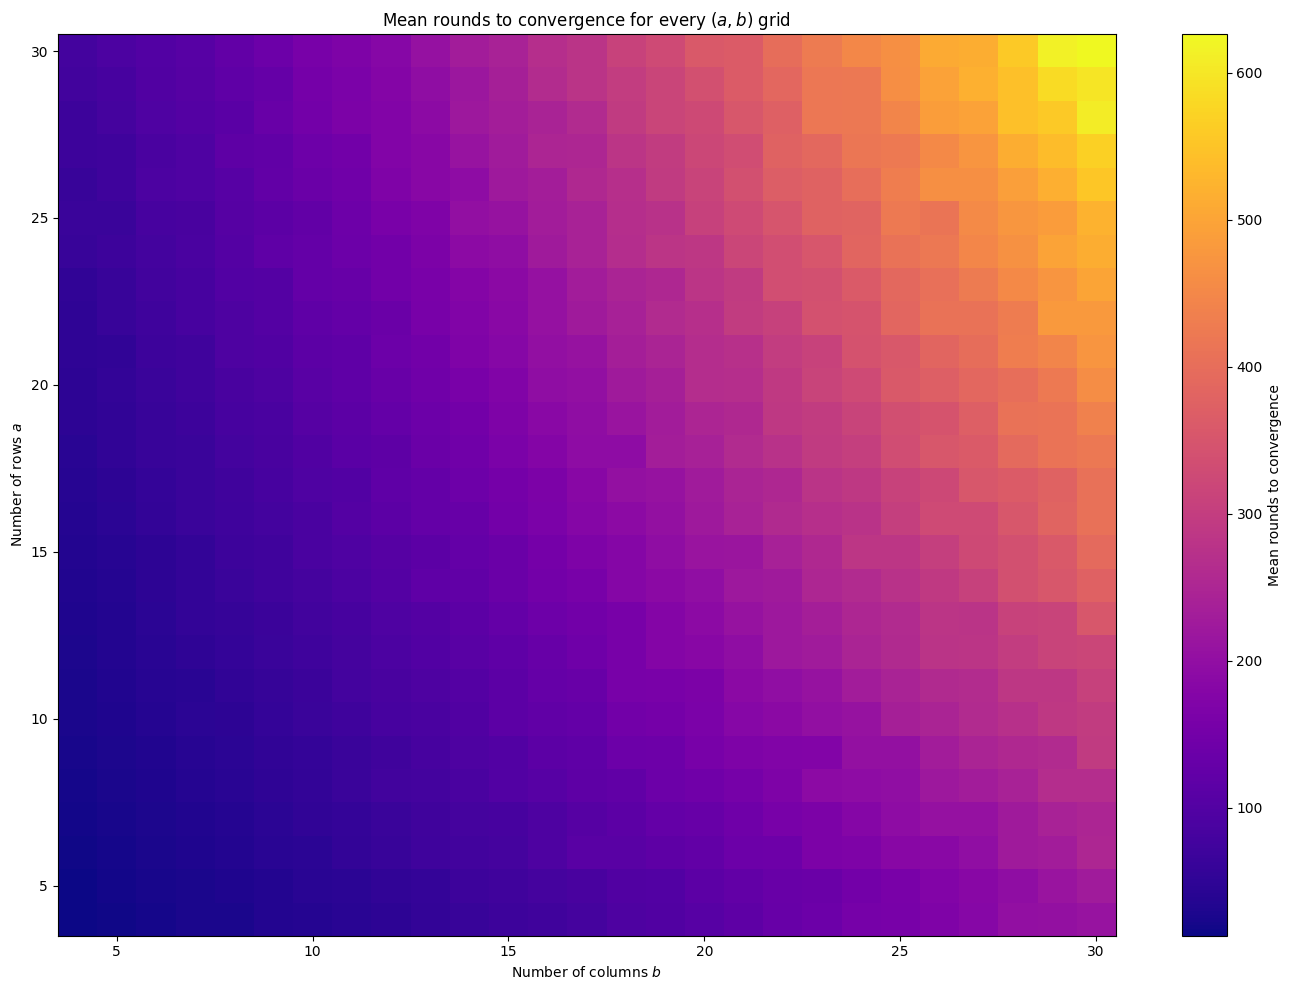

In [35]:
# --- Plot 6: 2D (a, b) heatmap of mean rounds ---
pivot = agg.pivot_table(index="a", columns="b", values="mean_steps", aggfunc="mean")

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="plasma",
               extent=[pivot.columns.min() - 0.5, pivot.columns.max() + 0.5,
                       pivot.index.min()   - 0.5, pivot.index.max()   + 0.5])
plt.colorbar(im, ax=ax, label="Mean rounds to convergence")
ax.set_xlabel("Number of columns $b$")
ax.set_ylabel("Number of rows $a$")
ax.set_title("Mean rounds to convergence for every $(a, b)$ grid")
plt.tight_layout()
plt.savefig(OUT_DIR / "heatmap_a_b_rounds.png", dpi=200)
plt.show()

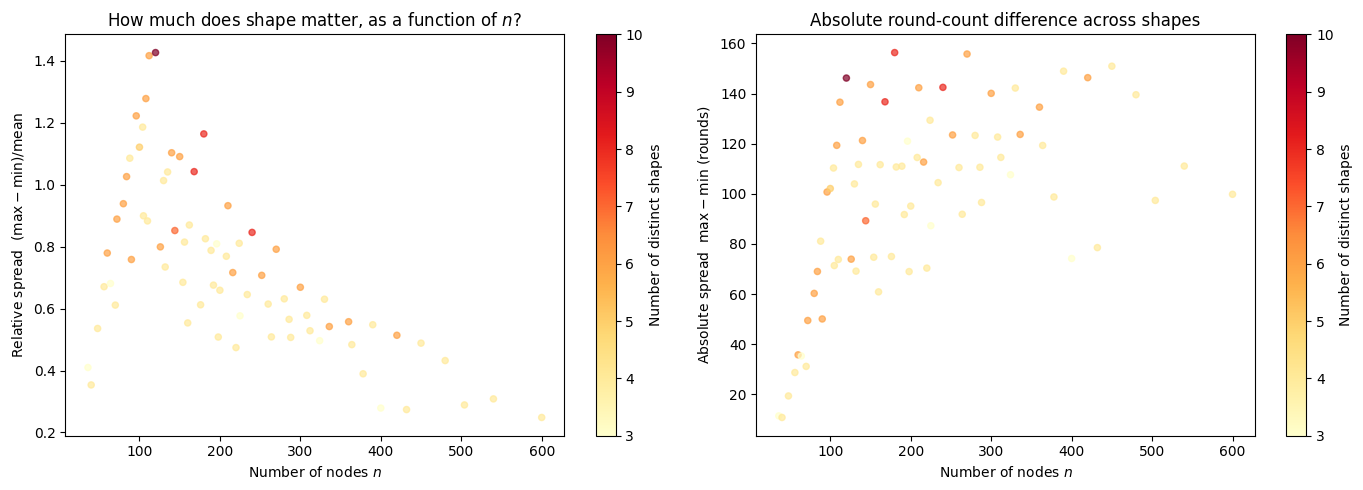

Relative spread summary:
count    73.000
mean      0.728
std       0.272
min       0.248
25%       0.536
50%       0.681
75%       0.883
max       1.427
Name: rel_spread, dtype: float64


In [36]:
# --- Plot 7: Shape effect magnitude vs n ---
# For each n with >= 3 shapes, compute the relative spread: (max - min) / mean
shape_stats = agg.groupby("n_nodes")["mean_steps"].agg(
    shape_count="count",
    shape_min="min",
    shape_max="max",
    shape_mean="mean",
)
shape_stats = shape_stats[shape_stats["shape_count"] >= 3].copy()
shape_stats["rel_spread"] = (shape_stats["shape_max"] - shape_stats["shape_min"]) / shape_stats["shape_mean"]
shape_stats = shape_stats.reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(shape_stats["n_nodes"], shape_stats["rel_spread"],
                c=shape_stats["shape_count"], cmap="YlOrRd", alpha=0.7, s=20)
sm = plt.cm.ScalarMappable(cmap="YlOrRd",
     norm=plt.Normalize(shape_stats["shape_count"].min(), shape_stats["shape_count"].max()))
plt.colorbar(sm, ax=axes[0], label="Number of distinct shapes")
axes[0].set_xlabel("Number of nodes $n$")
axes[0].set_ylabel("Relative spread  $(\\max - \\min) / \\mathrm{mean}$")
axes[0].set_title("How much does shape matter, as a function of $n$?")

axes[1].scatter(shape_stats["n_nodes"], shape_stats["shape_max"] - shape_stats["shape_min"],
                c=shape_stats["shape_count"], cmap="YlOrRd", alpha=0.7, s=20)
plt.colorbar(sm, ax=axes[1], label="Number of distinct shapes")
axes[1].set_xlabel("Number of nodes $n$")
axes[1].set_ylabel("Absolute spread  $\\max - \\min$ (rounds)")
axes[1].set_title("Absolute round-count difference across shapes")

plt.tight_layout()
plt.savefig(OUT_DIR / "shape_effect_magnitude.png", dpi=200)
plt.show()

print("Relative spread summary:")
print(shape_stats["rel_spread"].describe().round(3))

## Extended square-grid curve fit
Uses the dedicated square-grid CSV (a = b, up to 120×120) to fit time complexity over a much wider $n$ range without the noise from mixed factorizations.

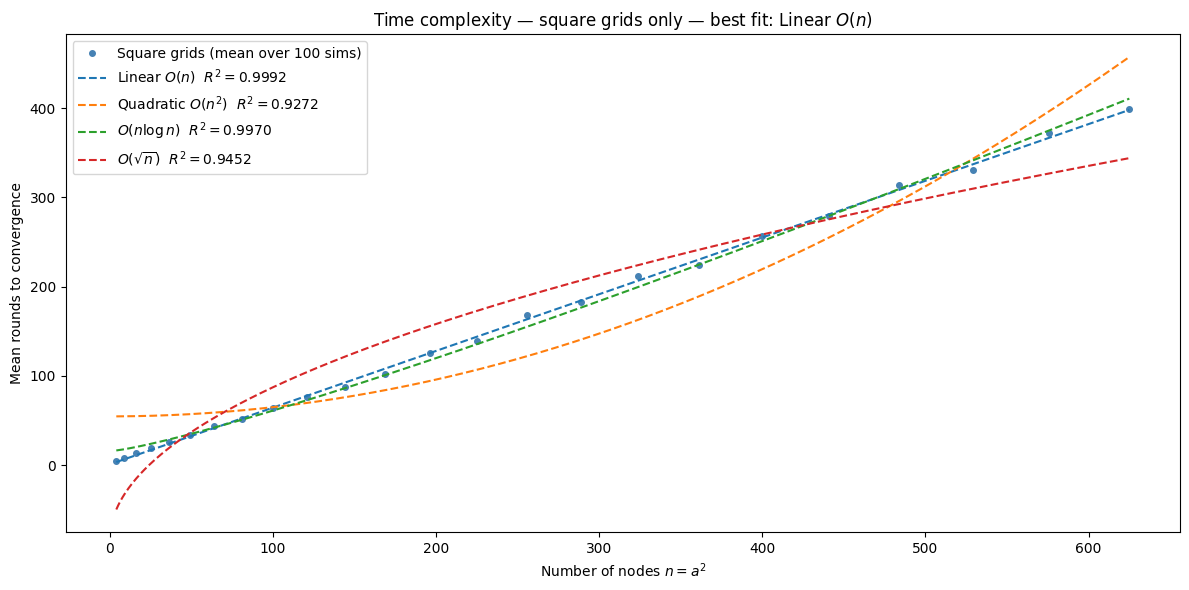

Best fit: Linear $O(n)$  (R² = 0.9992)
n range: 4 to 625  |  24 distinct grid sizes


In [38]:
# Load square-grid CSV (most recent matching file)
sq_csv_files = sorted(OUT_DIR.glob("square_grids_*.csv"))
if not sq_csv_files:
    print("No square-grid CSV found — run the extended section in time_complexity_runner.ipynb first.")
else:
    sq_df = pd.read_csv(sq_csv_files[-2])
    sq_df = sq_df[sq_df["success"] == 1].copy()
    sq_agg = sq_df.groupby("n_nodes")["steps"].mean().reset_index()
    sq_agg.columns = ["n_nodes", "mean_steps"]

    xs = sq_agg["n_nodes"].values.astype(float)
    ys = sq_agg["mean_steps"].values.astype(float)

    fits = {
        "Linear $O(n)$":      (lambda n, a, b: a * n + b,              [0.1, 1]),
        "Quadratic $O(n^2)$": (lambda n, a, b: a * n**2 + b,           [1e-6, 1]),
        "$O(n \\log n)$":     (lambda n, a, b: a * n * np.log(n) + b,  [0.01, 1]),
        "$O(\\sqrt{n})$":     (lambda n, a, b: a * np.sqrt(n) + b,     [1, 1]),
    }

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(xs, ys, "o", markersize=4, color="steelblue", label="Square grids (mean over 100 sims)")

    x_smooth = np.linspace(xs.min(), xs.max(), 500)
    best_r2, best_label = -np.inf, None

    for label, (fn, p0) in fits.items():
        try:
            popt, _ = curve_fit(fn, xs, ys, p0=p0, maxfev=10000)
            y_pred = fn(xs, *popt)
            ss_res = np.sum((ys - y_pred) ** 2)
            ss_tot = np.sum((ys - np.mean(ys)) ** 2)
            r2 = 1 - ss_res / ss_tot
            ax.plot(x_smooth, fn(x_smooth, *popt), "--", linewidth=1.5,
                    label=f"{label}  $R^2={r2:.4f}$")
            if r2 > best_r2:
                best_r2, best_label = r2, label
        except Exception as e:
            print(f"Fit failed for {label}: {e}")

    ax.set_xlabel("Number of nodes $n = a^2$")
    ax.set_ylabel("Mean rounds to convergence")
    ax.set_title(f"Time complexity — square grids only — best fit: {best_label}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "square_complexity_curve_fit.png", dpi=200)
    plt.show()
    print(f"Best fit: {best_label}  (R² = {best_r2:.4f})")
    print(f"n range: {int(xs.min())} to {int(xs.max()):,}  |  {len(sq_agg)} distinct grid sizes")

## O(n) vs O(n log n) discrimination — large log-spaced grids
Combines the dense small-n data with the large log-spaced points to fit both models
over a wide enough range to distinguish them.

In [43]:
# Load large log-spaced CSV (most recent)
lg_csv_files = sorted(OUT_DIR.glob("large_logspaced_*.csv"))
if not lg_csv_files:
    print("No large log-spaced CSV found — run the large log-spaced section in time_complexity_runner.ipynb first.")
else:
    lg_df = pd.read_csv(lg_csv_files[-2])
    lg_df = lg_df[lg_df["success"] == 1].copy()
    lg_agg = lg_df.groupby("n_nodes")["steps"].agg(["mean", "std", "count"]).reset_index()
    lg_agg.columns = ["n_nodes", "mean_steps", "std_steps", "count"]
    print(f"Loaded {len(lg_df):,} large-grid records from {lg_csv_files[-2].name}")
    print(lg_agg.to_string(index=False))

Loaded 18 large-grid records from large_logspaced_n2_100_424sims.csv
 n_nodes  mean_steps   std_steps  count
   10000      9547.0  362.038672      2
   12996     12933.0  608.111832      2
   16900     16739.5  300.520382      2
   21904     21871.5 2499.622471      2
   28561     27599.5 3124.704866      2
   37249     39105.0 2365.979290      2
   48400     51437.0 3734.938018      2
   63001     65886.5  498.510281      2
   81796     90392.0 7342.596816      2


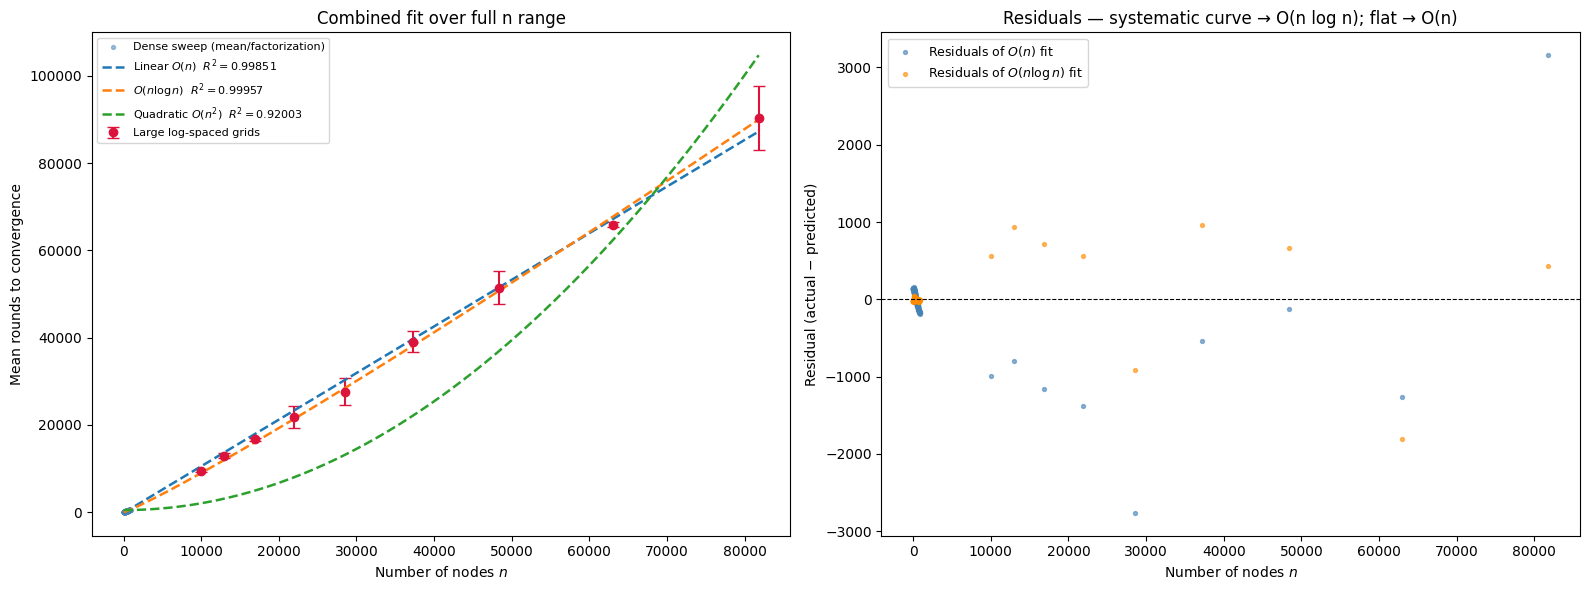


R² summary (combined fit):
  $O(n \log n)$              R²=0.99957
  Linear $O(n)$              R²=0.99851
  Quadratic $O(n^2)$         R²=0.92003


In [44]:
# --- Combined fit: dense small-n + sparse large-n ---
# Use per_n (from Plot 2, averaged over all factorizations) + large log-spaced points
combined = pd.concat([
    per_n.rename(columns={"mean_steps": "mean_steps"})[["n_nodes", "mean_steps"]],
    lg_agg[["n_nodes", "mean_steps"]],
], ignore_index=True).drop_duplicates("n_nodes").sort_values("n_nodes")

xc = combined["n_nodes"].values.astype(float)
yc = combined["mean_steps"].values.astype(float)

fits = {
    "Linear $O(n)$":      (lambda n, a, b: a * n + b,             [0.7, 1]),
    "$O(n \\log n)$":     (lambda n, a, b: a * n * np.log(n) + b, [0.1, 1]),
    "Quadratic $O(n^2)$": (lambda n, a, b: a * n**2 + b,          [1e-6, 1]),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: combined data + fits
axes[0].scatter(per_n["n_nodes"], per_n["mean_steps"],
                s=8, alpha=0.5, color="steelblue", label="Dense sweep (mean/factorization)")
axes[0].errorbar(lg_agg["n_nodes"], lg_agg["mean_steps"],
                 yerr=lg_agg["std_steps"], fmt="o", color="crimson",
                 capsize=4, markersize=6, label="Large log-spaced grids")

x_smooth = np.linspace(xc.min(), xc.max(), 600)
r2s = {}
for label, (fn, p0) in fits.items():
    try:
        popt, _ = curve_fit(fn, xc, yc, p0=p0, maxfev=20000)
        y_pred = fn(xc, *popt)
        r2 = 1 - np.sum((yc - y_pred)**2) / np.sum((yc - yc.mean())**2)
        r2s[label] = r2
        axes[0].plot(x_smooth, fn(x_smooth, *popt), "--", linewidth=1.8,
                     label=f"{label}  $R^2={r2:.5f}$")
    except Exception as e:
        print(f"Fit failed for {label}: {e}")

axes[0].set_xlabel("Number of nodes $n$")
axes[0].set_ylabel("Mean rounds to convergence")
axes[0].set_title("Combined fit over full n range")
axes[0].legend(fontsize=8)

# Right: residuals of O(n) fit to highlight systematic curvature
try:
    popt_n, _ = curve_fit(lambda n, a, b: a*n+b, xc, yc, p0=[0.7,1])
    popt_nl, _ = curve_fit(lambda n, a, b: a*n*np.log(n)+b, xc, yc, p0=[0.1,1])
    resid_n  = yc - (popt_n[0]*xc  + popt_n[1])
    resid_nl = yc - (popt_nl[0]*xc*np.log(xc) + popt_nl[1])
    axes[1].scatter(xc, resid_n,  s=8, alpha=0.6, label="Residuals of $O(n)$ fit",      color="steelblue")
    axes[1].scatter(xc, resid_nl, s=8, alpha=0.6, label="Residuals of $O(n\\log n)$ fit", color="darkorange")
    axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
    axes[1].set_xlabel("Number of nodes $n$")
    axes[1].set_ylabel("Residual (actual − predicted)")
    axes[1].set_title("Residuals — systematic curve → O(n log n); flat → O(n)")
    axes[1].legend(fontsize=9)
except Exception as e:
    print(f"Residual plot failed: {e}")

plt.tight_layout()
plt.savefig(OUT_DIR / "on_vs_onlogn_combined.png", dpi=200)
plt.show()

print("\nR² summary (combined fit):")
for label, r2 in sorted(r2s.items(), key=lambda x: -x[1]):
    print(f"  {label:25s}  R²={r2:.5f}")